In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [21]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [22]:
print(df.shape)

print(df.info())

print(df.describe())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611

In [23]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


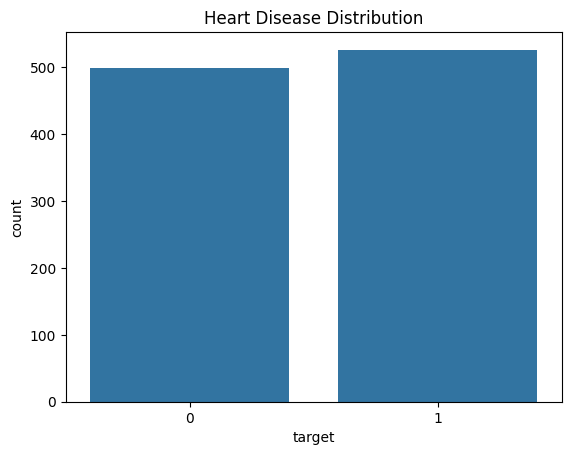

In [24]:
sns.countplot(
    x='target',
    data=df
)

plt.title(
    "Heart Disease Distribution"
)

plt.show()

In [25]:
print(df.shape)
print(df.duplicated().sum())

(1025, 14)
723


In [26]:
df = df.drop_duplicates()

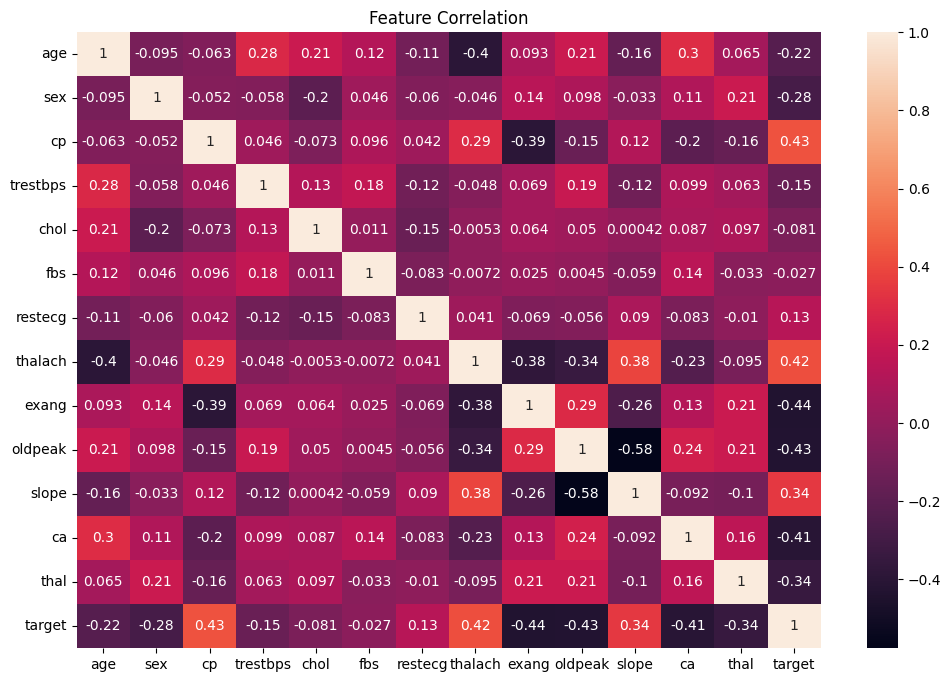

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title(
    "Feature Correlation"
)

plt.show()

plt.savefig(
    "correlation_heatmap.png",
    bbox_inches='tight'
)

In [28]:
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [31]:
#training multiple models
models = {

    "Logistic Regression":
        LogisticRegression(),

    "SVM":
        SVC(probability=True),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}

In [32]:
#comparing all models
for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    print("\n",name)

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            pred
        )
    )

    print(
        classification_report(
            y_test,
            pred
        )
    )


 Logistic Regression
Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


 SVM
Accuracy: 0.7704918032786885
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61


 Random Forest
Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        

In [38]:
#as logistic regression is best as per accuracy
best_model = LogisticRegression()

best_model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [39]:
probs = best_model.predict_proba(
    X_test
)[:,1]

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)

ROC-AUC: 0.8712121212121212


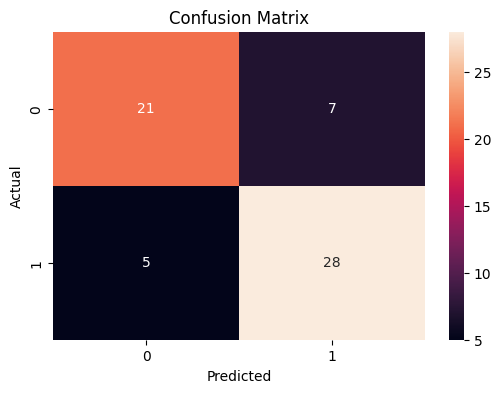

<Figure size 640x480 with 0 Axes>

In [40]:
cm = confusion_matrix(
    y_test,
    best_model.predict(X_test)
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

plt.savefig(
    "confusion_matrix.png",
    bbox_inches='tight'
)

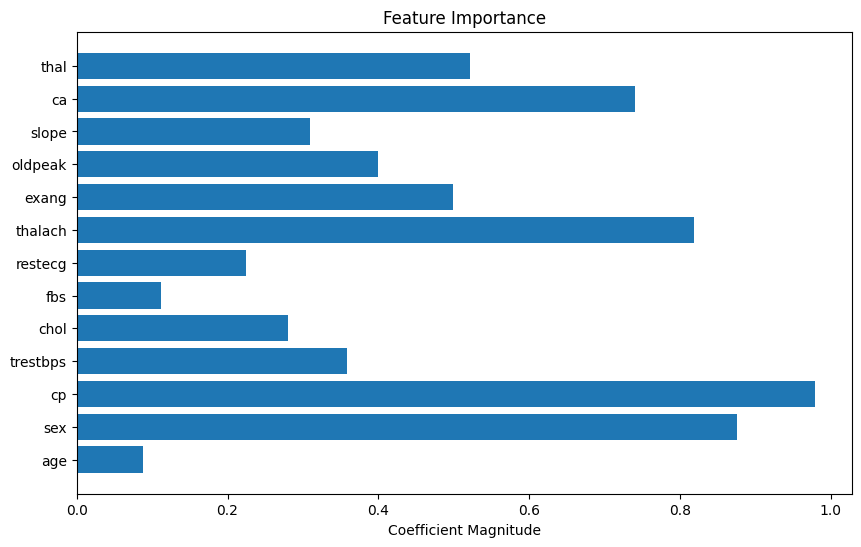

<Figure size 640x480 with 0 Axes>

In [43]:
importance = abs(best_model.coef_[0])

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.xlabel("Coefficient Magnitude")

plt.title("Feature Importance")

plt.show()

plt.savefig(
    "feature_importance.png",
    bbox_inches='tight'
)

In [44]:
import joblib

joblib.dump(
    best_model,
    "disease_prediction_model.pkl"
)

joblib.dump(
    scaler,
    "scaler1.pkl"
)

print("Saved successfully")

Saved successfully


In [45]:
import os

print(os.listdir())

['.config', 'confusion_matrix.png', 'disease_model.pkl', 'feature_importance.png', 'scaler1.pkl', 'disease_prediction_model.pkl', 'heart.csv', 'correlation_heatmap.png', 'scaler.pkl', 'sample_data']


In [46]:
from google.colab import files

files.download(
    "disease_prediction_model.pkl"
)

files.download(
    "scaler1.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>